# Plan 3 — Scaffold-Diversity vs Split-Degradation (P3-T18)

Per-target scaffold-diversity metrics (n_scaffolds, scaffold_entropy,
largest_cluster_fraction, mean_tanimoto, activity_cliff_frequency) are
regressed against per-target degradation between splits (random → scaffold,
scaffold → target) for both **kinase** and **GPCR-aminergic** classes. The
class × metric interaction term tests whether the metric-degradation
relationship differs between classes (pre-registered cross-class question
from Plan 3 design spec §4.3 / spec 5.1).

**Primary model:** `random_forest` (canonical baseline reported across
all splits; per-target RMSE files materialized for both classes).

**Outputs:**
- `results/figures/figure3_scaffold_degradation.png` — main-text Figure 3
- `results/tables/04_metric_correlations_scaffold.csv` — main-text Table 4 (scaffold portion)


In [1]:
"""Plan 3 P3-T18 — Scaffold-diversity vs split-degradation cross-class analysis.

Pre-registered hypothesis (from Plan 3 design spec Section 4.3 / spec 5.1):
  - Per-target degradation (random→scaffold + scaffold→target) correlates with
    per-target scaffold-diversity metrics.
  - Cross-class question: do the slopes differ between kinase and GPCR classes?
    Tested via the class × metric interaction in fit_degradation_regression.

Inputs:
  data/processed/v1/per_target/per_target_<model>_<split>.csv      (GPCR, 7 × 3 = 21 files)
  data/kinase_reference/benchmark_v1/per_target/per_target_<model>_<split>.csv  (kinase, 21 files)
  results/supplement/per_target_metrics_scaffold.csv               (T12 output)

Outputs:
  results/figures/figure3_scaffold_degradation.png
  results/tables/04_metric_correlations_scaffold.csv
"""
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from target_affinity_ml.benchmarks.scaffold_diversity import fit_degradation_regression

REPO_ROOT = Path.cwd().parent  # notebook runs from notebooks/
print(f"Repo: {REPO_ROOT}")


Repo: /Users/joshuaabbott/gpcr-aminergic-benchmarks


In [2]:
# Load per-target scaffold-diversity metrics (T12 output)
scaffold_path = REPO_ROOT / "results/supplement/per_target_metrics_scaffold.csv"
scaffold = pd.read_csv(scaffold_path)
print(f"Loaded {len(scaffold)} per-target rows")
print(scaffold.groupby("class_name").size())
scaffold.head()


Loaded 543 per-target rows
class_name
gpcr_aminergic     36
kinase            507
dtype: int64


,target_chembl_id,n_compounds,n_scaffolds,scaffold_entropy,largest_cluster_fraction,mean_tanimoto,activity_cliff_frequency,class_name
0,CHEMBL1805,116,60,3.483950,0.172414,0.331257,0.001,gpcr_aminergic
1,CHEMBL1821,1299,594,5.717535,0.046189,0.160264,0.000,gpcr_aminergic
2,CHEMBL1833,1792,707,5.915997,0.025112,0.117708,0.000,gpcr_aminergic
3,CHEMBL1850,362,185,4.735997,0.066298,0.167088,0.001,gpcr_aminergic
4,CHEMBL1867,1068,541,5.800066,0.031835,0.120906,0.000,gpcr_aminergic


In [3]:
# Load per-target degradation from both classes (random_forest, the canonical baseline).
# Schemas confirmed: both files use column "target_id" (not "target_chembl_id").

def load_per_target_rmse(per_target_dir: Path, model: str, split: str) -> pd.DataFrame:
    """Load a per-target RMSE file; return DataFrame with target_chembl_id + rmse + n_compounds."""
    path = per_target_dir / f"per_target_{model}_{split}.csv"
    df = pd.read_csv(path)
    return df[["target_id", "rmse", "n_compounds"]].rename(columns={"target_id": "target_chembl_id"})


def degradation_for_class(per_target_dir: Path, class_name: str, model: str = "random_forest") -> pd.DataFrame:
    """Per-target degradation values for one class+model.

    Returns DataFrame with: target_chembl_id, class_name, n_compounds,
    rmse_random, rmse_scaffold, rmse_target, delta_random_to_scaffold, delta_scaffold_to_target.
    """
    rand = load_per_target_rmse(per_target_dir, model, "random").rename(
        columns={"rmse": "rmse_random"}
    )
    scaff = load_per_target_rmse(per_target_dir, model, "scaffold").rename(
        columns={"rmse": "rmse_scaffold", "n_compounds": "n_compounds_scaff"}
    )
    targ = load_per_target_rmse(per_target_dir, model, "target").rename(
        columns={"rmse": "rmse_target", "n_compounds": "n_compounds_targ"}
    )
    df = rand.merge(scaff[["target_chembl_id", "rmse_scaffold"]], on="target_chembl_id", how="inner")
    df = df.merge(targ[["target_chembl_id", "rmse_target"]], on="target_chembl_id", how="left")
    df["delta_random_to_scaffold"] = df["rmse_scaffold"] - df["rmse_random"]
    df["delta_scaffold_to_target"] = df["rmse_target"] - df["rmse_scaffold"]
    df["class_name"] = class_name
    return df


gpcr_deg = degradation_for_class(
    REPO_ROOT / "data/processed/v1/per_target", "gpcr_aminergic"
)
kinase_deg = degradation_for_class(
    REPO_ROOT / "data/kinase_reference/benchmark_v1/per_target", "kinase"
)
print(f"GPCR   per-target with degradation: {len(gpcr_deg)} targets "
      f"(target-split rows: {gpcr_deg['rmse_target'].notna().sum()})")
print(f"Kinase per-target with degradation: {len(kinase_deg)} targets "
      f"(target-split rows: {kinase_deg['rmse_target'].notna().sum()})")

degradation = pd.concat([gpcr_deg, kinase_deg], ignore_index=True)
degradation.head()


GPCR   per-target with degradation: 36 targets (target-split rows: 5)
Kinase per-target with degradation: 199 targets (target-split rows: 24)


,target_chembl_id,rmse_random,n_compounds,rmse_scaffold,rmse_target,delta_random_to_scaffold,delta_scaffold_to_target,class_name
0,CHEMBL1805,1.261038,70.0,1.185799,1.25096,-0.075239,0.065161,gpcr_aminergic
1,CHEMBL1821,0.645758,710.0,0.757658,NaN,0.111900,NaN,gpcr_aminergic
2,CHEMBL1833,0.802501,865.0,0.993189,NaN,0.190687,NaN,gpcr_aminergic
3,CHEMBL1850,1.089626,200.0,1.240430,NaN,0.150805,NaN,gpcr_aminergic
4,CHEMBL1867,0.879640,530.0,1.052732,0.98367,0.173092,-0.069062,gpcr_aminergic


In [4]:
# Join scaffold metrics + degradation on (target_chembl_id, class_name).
joined = scaffold.merge(
    degradation[
        [
            "target_chembl_id",
            "class_name",
            "rmse_random",
            "rmse_scaffold",
            "rmse_target",
            "delta_random_to_scaffold",
            "delta_scaffold_to_target",
        ]
    ],
    on=["target_chembl_id", "class_name"],
    how="inner",
)
print(f"Joined: {len(joined)} targets (with scaffold metrics + degradation)")
print(joined.groupby("class_name").size())
joined[
    [
        "target_chembl_id",
        "class_name",
        "n_scaffolds",
        "scaffold_entropy",
        "delta_random_to_scaffold",
        "delta_scaffold_to_target",
    ]
].head()


Joined: 235 targets (with scaffold metrics + degradation)
class_name
gpcr_aminergic     36
kinase            199
dtype: int64


,target_chembl_id,class_name,n_scaffolds,scaffold_entropy,delta_random_to_scaffold,delta_scaffold_to_target
0,CHEMBL1805,gpcr_aminergic,60,3.483950,-0.075239,0.065161
1,CHEMBL1821,gpcr_aminergic,594,5.717535,0.111900,NaN
2,CHEMBL1833,gpcr_aminergic,707,5.915997,0.190687,NaN
3,CHEMBL1850,gpcr_aminergic,185,4.735997,0.150805,NaN
4,CHEMBL1867,gpcr_aminergic,541,5.800066,0.173092,-0.069062


In [5]:
# Run per-class regressions for each (metric × direction) pair.
# fit_degradation_regression pools both classes, estimates per-class slopes via
# the class × metric interaction, and reports the cross-class interaction p-value.
# Requires ≥3 obs per class. GPCR target-split only has ~5 targets, so the
# delta_scaffold_to_target direction will have very low power for the
# interaction test on the GPCR side. We surface n_per_class so this is visible.

METRICS = [
    "n_scaffolds",
    "scaffold_entropy",
    "largest_cluster_fraction",
    "mean_tanimoto",
    "activity_cliff_frequency",
]
DIRECTIONS = ["delta_random_to_scaffold", "delta_scaffold_to_target"]

results_rows = []
for direction in DIRECTIONS:
    for metric in METRICS:
        sub = joined.dropna(subset=[metric, direction])
        n_per_class = sub.groupby("class_name").size().to_dict()
        if min(n_per_class.values(), default=0) < 3:
            print(f"  SKIP {direction} ~ {metric}: insufficient n_per_class={n_per_class}")
            continue
        try:
            r = fit_degradation_regression(sub, metric, direction, class_col="class_name")
        except ValueError as e:
            print(f"  ERROR {direction} ~ {metric}: {e}")
            continue
        slopes = r["slopes"]
        # Per-class keys come from the literal class_name values present in the data.
        kin_key = "kinase" if "kinase" in slopes else next(iter(slopes))
        gpcr_key = "gpcr_aminergic" if "gpcr_aminergic" in slopes else (
            [k for k in slopes if k != kin_key][0] if len(slopes) > 1 else kin_key
        )
        results_rows.append(
            {
                "direction": direction,
                "metric": metric,
                "n_obs": r["n_obs"],
                "n_kinase": r["n_per_class"].get(kin_key),
                "n_gpcr": r["n_per_class"].get(gpcr_key),
                "r_squared": r["r_squared"],
                "intercept": r["intercept"],
                "slope_kinase": slopes[kin_key]["slope"],
                "slope_kinase_p": slopes[kin_key]["p_value"],
                "slope_kinase_ci_low": slopes[kin_key]["ci_low"],
                "slope_kinase_ci_high": slopes[kin_key]["ci_high"],
                "slope_gpcr": slopes[gpcr_key]["slope"],
                "slope_gpcr_p": slopes[gpcr_key]["p_value"],
                "slope_gpcr_ci_low": slopes[gpcr_key]["ci_low"],
                "slope_gpcr_ci_high": slopes[gpcr_key]["ci_high"],
                "interaction_p": r["interaction_p"],
            }
        )

results = pd.DataFrame(results_rows)
print(f"\n{len(results)} regression rows fitted")
results



10 regression rows fitted


,direction,metric,n_obs,n_kinase,n_gpcr,r_squared,intercept,slope_kinase,slope_kinase_p,slope_kinase_ci_low,slope_kinase_ci_high,slope_gpcr,slope_gpcr_p,slope_gpcr_ci_low,slope_gpcr_ci_high,interaction_p
0,delta_random_to_scaffold,n_scaffolds,235,199,36,0.004070,0.129199,-9.052839e-06,0.573105,-0.000041,0.000023,0.000005,0.901089,-0.000072,0.000081,0.741471
1,delta_random_to_scaffold,scaffold_entropy,235,199,36,0.041390,-0.356639,-7.514121e-03,0.540186,-0.031648,0.016620,0.085907,0.003054,0.029372,0.142441,0.003049
2,delta_random_to_scaffold,largest_cluster_fraction,235,199,36,0.091175,0.271628,2.051579e-01,0.178436,-0.094333,0.504649,-2.707519,0.000009,-3.880482,-1.534556,0.000004
3,delta_random_to_scaffold,mean_tanimoto,235,199,36,0.030615,0.450149,-3.733131e-02,0.868231,-0.480183,0.405520,-1.906740,0.010588,-3.364553,-0.448926,0.016404
4,delta_random_to_scaffold,activity_cliff_frequency,235,199,36,0.010172,0.128891,-6.585947e+00,0.198200,-16.641865,3.469972,14.617841,0.758363,-78.894057,108.129739,0.657313
5,delta_scaffold_to_target,n_scaffolds,29,24,5,0.064063,-0.033218,-7.729060e-07,0.993241,-0.000187,0.000185,-0.000014,0.954540,-0.000531,0.000502,0.959509
6,delta_scaffold_to_target,scaffold_entropy,29,24,5,0.120002,0.142087,-6.150028e-02,0.236212,-0.165862,0.042862,-0.033515,0.732178,-0.232963,0.165934,0.800009
7,delta_scaffold_to_target,largest_cluster_fraction,29,24,5,0.110561,-0.096371,1.081523e+00,0.310999,-1.072507,3.235553,0.899170,0.627626,-2.871556,4.669897,0.931771
8,delta_scaffold_to_target,mean_tanimoto,29,24,5,0.437876,-0.174992,2.309376e+00,0.000483,1.123322,3.495430,0.763225,0.465480,-1.357525,2.883976,0.201939
9,delta_scaffold_to_target,activity_cliff_frequency,29,24,5,0.106899,-0.037241,4.605996e+01,0.284064,-40.592462,132.712374,-13.715251,0.948959,-450.572939,423.142436,0.784497


In [6]:
# Save Table 4 (scaffold portion). T19 will append pLDDT rows.
tables_dir = REPO_ROOT / "results/tables"
tables_dir.mkdir(parents=True, exist_ok=True)
out_path = tables_dir / "04_metric_correlations_scaffold.csv"
results.to_csv(out_path, index=False)
print(f"Wrote {len(results)} rows to {out_path}")


Wrote 10 rows to /Users/joshuaabbott/gpcr-aminergic-benchmarks/results/tables/04_metric_correlations_scaffold.csv


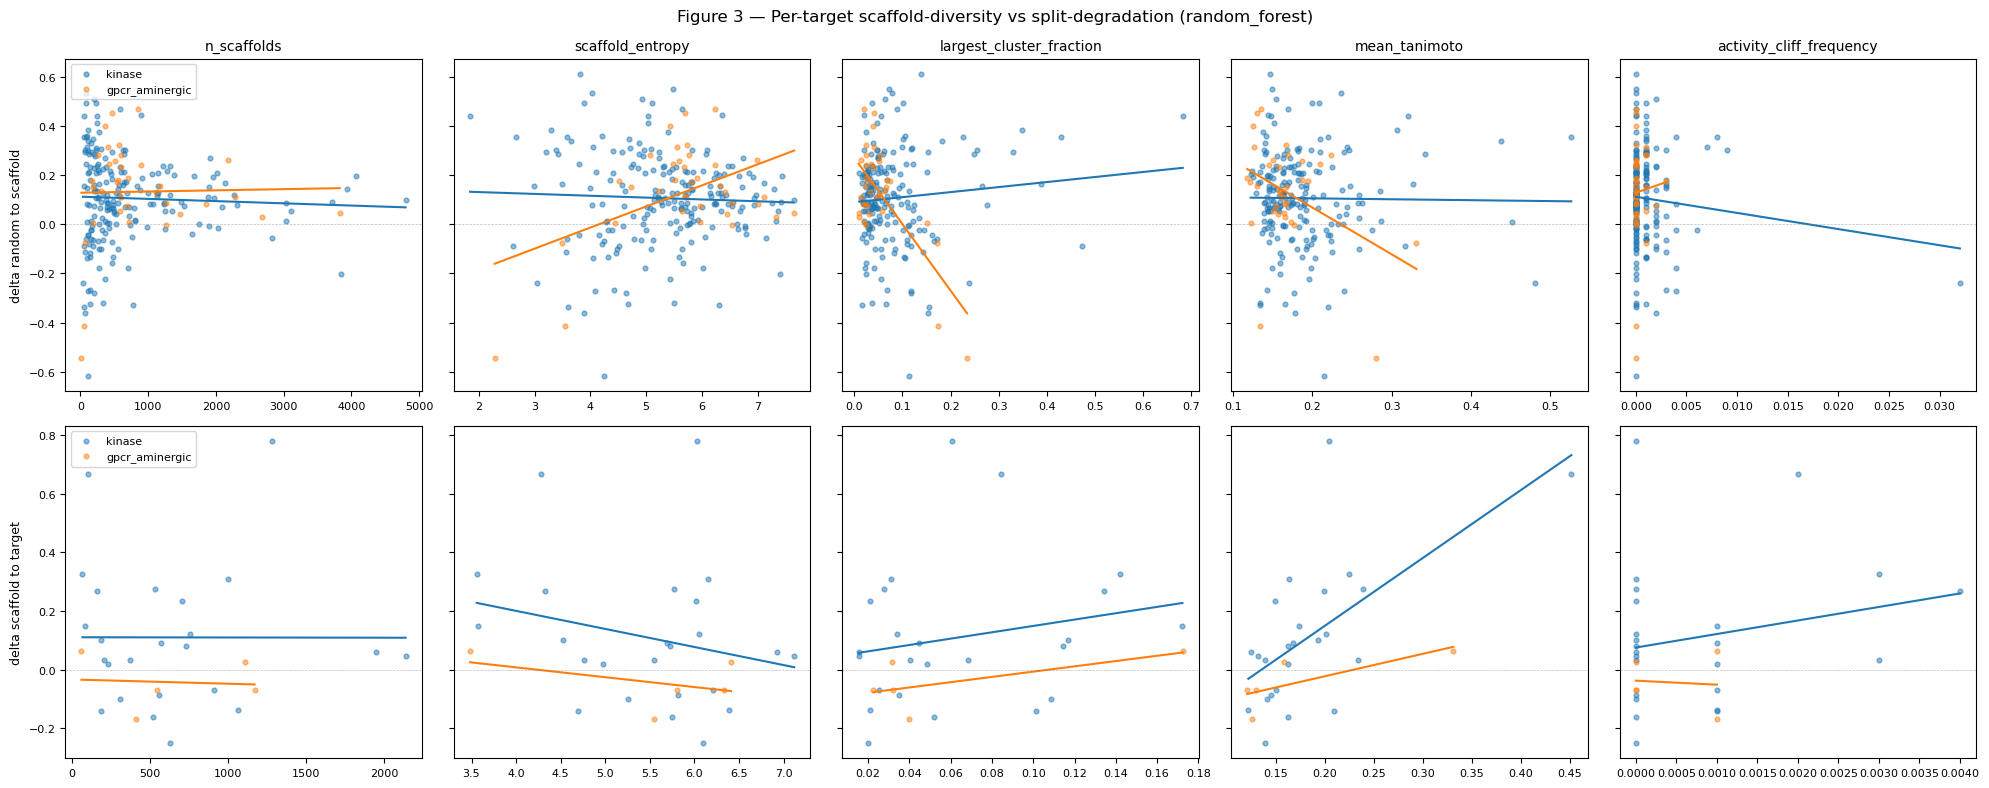

Wrote /Users/joshuaabbott/gpcr-aminergic-benchmarks/results/figures/figure3_scaffold_degradation.png


In [7]:
# Figure 3 — scatter + per-class regression lines.
# 2 rows (degradation directions) × 5 columns (scaffold metrics).
fig, axes = plt.subplots(
    len(DIRECTIONS), len(METRICS), figsize=(20, 8), sharey="row"
)
class_styles = [("kinase", "tab:blue"), ("gpcr_aminergic", "tab:orange")]
for i, direction in enumerate(DIRECTIONS):
    for j, metric in enumerate(METRICS):
        ax = axes[i, j]
        sub = joined.dropna(subset=[metric, direction])
        for cls, color in class_styles:
            sub_cls = sub[sub["class_name"] == cls]
            if len(sub_cls) == 0:
                continue
            ax.scatter(
                sub_cls[metric],
                sub_cls[direction],
                alpha=0.5,
                s=12,
                color=color,
                label=cls,
            )
            if len(sub_cls) >= 2:
                x_line = np.linspace(sub_cls[metric].min(), sub_cls[metric].max(), 50)
                slope, intercept = np.polyfit(sub_cls[metric], sub_cls[direction], 1)
                ax.plot(x_line, slope * x_line + intercept, color=color, linewidth=1.5)
        ax.axhline(0, color="gray", linewidth=0.5, linestyle="--", alpha=0.5)
        if i == 0:
            ax.set_title(metric, fontsize=10)
        if j == 0:
            ax.set_ylabel(direction.replace("_", " "), fontsize=9)
        ax.tick_params(axis="both", labelsize=8)
    axes[i, 0].legend(loc="upper left", fontsize=8)

fig.suptitle(
    "Figure 3 — Per-target scaffold-diversity vs split-degradation (random_forest)",
    fontsize=12,
)
plt.tight_layout()
figures_dir = REPO_ROOT / "results/figures"
figures_dir.mkdir(parents=True, exist_ok=True)
fig_path = figures_dir / "figure3_scaffold_degradation.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Wrote {fig_path}")


In [8]:
# Interpretation summary.
# Note: delta_scaffold_to_target on the GPCR side has very few finite values
# (target-split test set is only 5 GPCR-aminergic targets) — the interaction
# test in that direction has minimal power.

print("=== Headline findings (random_forest) ===\n")
for _, row in results.iterrows():
    interp = (
        "differ across classes"
        if row["interaction_p"] < 0.05
        else "consistent across classes"
    )
    print(f"{row['direction']} ~ {row['metric']}  (n_kinase={row['n_kinase']}, n_gpcr={row['n_gpcr']}):")
    print(
        f"  kinase slope: {row['slope_kinase']:+.4f} "
        f"({row['slope_kinase_ci_low']:+.4f}, {row['slope_kinase_ci_high']:+.4f}), "
        f"p={row['slope_kinase_p']:.4f}"
    )
    print(
        f"  GPCR slope:   {row['slope_gpcr']:+.4f} "
        f"({row['slope_gpcr_ci_low']:+.4f}, {row['slope_gpcr_ci_high']:+.4f}), "
        f"p={row['slope_gpcr_p']:.4f}"
    )
    print(
        f"  interaction p={row['interaction_p']:.4f}  → {interp}  "
        f"(R²={row['r_squared']:.3f})"
    )
    print()


=== Headline findings (random_forest) ===

delta_random_to_scaffold ~ n_scaffolds  (n_kinase=199, n_gpcr=36):
  kinase slope: -0.0000 (-0.0000, +0.0000), p=0.5731
  GPCR slope:   +0.0000 (-0.0001, +0.0001), p=0.9011
  interaction p=0.7415  → consistent across classes  (R²=0.004)

delta_random_to_scaffold ~ scaffold_entropy  (n_kinase=199, n_gpcr=36):
  kinase slope: -0.0075 (-0.0316, +0.0166), p=0.5402
  GPCR slope:   +0.0859 (+0.0294, +0.1424), p=0.0031
  interaction p=0.0030  → differ across classes  (R²=0.041)

delta_random_to_scaffold ~ largest_cluster_fraction  (n_kinase=199, n_gpcr=36):
  kinase slope: +0.2052 (-0.0943, +0.5046), p=0.1784
  GPCR slope:   -2.7075 (-3.8805, -1.5346), p=0.0000
  interaction p=0.0000  → differ across classes  (R²=0.091)

delta_random_to_scaffold ~ mean_tanimoto  (n_kinase=199, n_gpcr=36):
  kinase slope: -0.0373 (-0.4802, +0.4055), p=0.8682
  GPCR slope:   -1.9067 (-3.3646, -0.4489), p=0.0106
  interaction p=0.0164  → differ across classes  (R²=0.031